In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from stable_baselines3 import PPO
from multi_ticker_env import MultiTickerTradingEnv

# 📁 Charger les données
file_path = "/Users/yassinf/GIT/Projet_trading_automatique/Data/cac40_clean_format.csv"
df = pd.read_csv(file_path)

# 📊 Pivot + nettoyage
df = df[df["Price"].isin(["Open", "High", "Low", "Close", "Volume"])]
df = df.pivot(index=["Datetime", "Ticker"], columns="Price", values="Value").reset_index()
df.columns.name = None
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values(by=["Datetime", "Ticker"]).reset_index(drop=True)
df = df.ffill().bfill()

# 📅 Filtrer la période de backtest
df_test = df[(df["Datetime"] >= "2024-03-01") & (df["Datetime"] <= "2025-03-01")].copy()
tickers = df_test["Ticker"].unique().tolist()
df_test = df_test[df_test["Ticker"].isin(tickers)]

print("📅 Période de backtest : 2024-03-01 → 2025-03-01")
print(f"🧠 Tickers testés : {tickers}")

# 🧠 Charger le modèle
model = PPO.load("/Users/yassinf/GIT/Projet_trading_automatique/ppo_multi_model_iter_1.zip")

# 🌍 Créer l’environnement
env = MultiTickerTradingEnv(df_test, tickers=tickers)
print(f"💰 Solde initial dans le backtest : {env.initial_balance}")

# 🚀 Backtest
obs = env.reset()
done = False
signaux = []

print("📈 Backtest en cours...")
for _ in tqdm(range(env.max_steps)):
    action, _ = model.predict(obs)
    obs, reward, done, _ = env.step(action)
    current_date = df_test["Datetime"].unique()[env.current_step]

    for i, act in enumerate(action):
        try:
            price_filter = df_test[(df_test["Datetime"] == current_date) & (df_test["Ticker"] == tickers[i])]
            price = price_filter["Close"].values[0] if not price_filter.empty else np.nan
        except IndexError:
            price = np.nan  # en cas de donnée manquante

        signal = {
            "Date":  current_date,
            "Ticker": tickers[i],
            "Action": ["HOLD", "BUY", "SELL"][act],
            "Price": price,
            "Balance": env.balance,
            "Total_Value": env.total_value
        }
        signaux.append(signal)


    if done:
        break

# 💾 Enregistrer les signaux
signals_df = pd.DataFrame(signaux)
signals_df.to_csv("backtest_signaux.csv", index=False)



# ✅ Résumé final
print("\n✅ Backtest terminé !")
print(f"📊 Balance finale : {env.balance:.2f} €")
print(f"💰 Valeur totale du portefeuille : {env.total_value:.2f} €")


📅 Période de backtest : 2024-03-01 → 2025-03-01
🧠 Tickers testés : ['AC.PA', 'ACA.PA', 'AI.PA', 'AIR.PA', 'BN.PA', 'BNP.PA', 'CA.PA', 'CAP.PA', 'CS.PA', 'DG.PA', 'DSY.PA', 'EDEN.PA', 'EL.PA', 'EN.PA', 'ENGI.PA', 'ERF.PA', 'GLE.PA', 'HO.PA', 'KER.PA', 'LR.PA', 'MC.PA', 'ML.PA', 'MT.AS', 'OR.PA', 'ORA.PA', 'PUB.PA', 'RI.PA', 'RMS.PA', 'RNO.PA', 'SAF.PA', 'SAN.PA', 'SGO.PA', 'STLAP.PA', 'STMPA.PA', 'SU.PA', 'TEP.PA', 'TTE.PA', 'URW.PA', 'VIE.PA', 'VIV.PA']
💰 Solde initial dans le backtest : 10000
📈 Backtest en cours...


100%|█████████▉| 253/254 [01:53<00:00,  2.24it/s]


✅ Backtest terminé !
📊 Balance finale : 6280.87 €
💰 Valeur totale du portefeuille : 10059.99 €


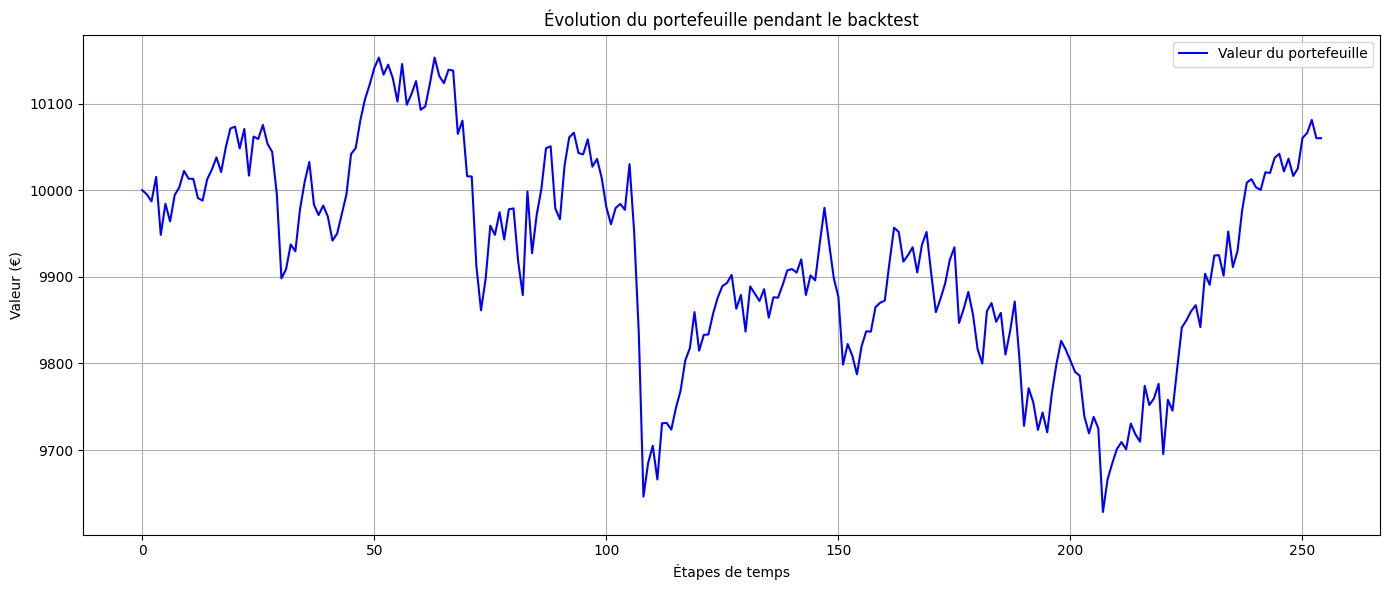

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(env.portfolio_history, label="Valeur du portefeuille", color="blue")
plt.xlabel("Étapes de temps")
plt.ylabel("Valeur (€)")
plt.title("Évolution du portefeuille pendant le backtest")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [6]:
import pandas as pd
import numpy as np

# 📂 Charger le fichier de signaux
df = pd.read_csv("backtest_signaux.csv")

# 🧼 Nettoyage (au cas où)
df = df.dropna(subset=["Total_Value"])

# 📊 Statistiques de Performance
valeur_initiale = 10000  # Solde initial]
valeur_finale = df["Total_Value"].iloc[-1]
rendement = (valeur_finale - valeur_initiale) / valeur_initiale

# 🧾 Compter les types de trades
nb_achats = (df["Action"] == "BUY").sum()
nb_ventes = (df["Action"] == "SELL").sum()
nb_trades = nb_achats + nb_ventes

# 📈 Ratio de Sharpe (retours journaliers)
df["Return"] = df["Total_Value"].pct_change()
sharpe_ratio = df["Return"].mean() / df["Return"].std()
sharpe_ratio_annualisé = sharpe_ratio * np.sqrt(252)

# 📤 Affichage
print("📊 Statistiques de Performance")
print(f"➡️ Valeur initiale : {valeur_initiale:.2f} €")
print(f"➡️ Valeur finale : {valeur_finale:.2f} €")
print(f"➡️ Rendement final : {rendement * 100:.2f} %")
print(f"➡️ Nombre total de trades : {nb_trades}")
print(f"➡️ Nombre d’achats : {nb_achats}")
print(f"➡️ Nombre de ventes : {nb_ventes}")
print(f"➡️ Ratio de Sharpe annualisé : {sharpe_ratio_annualisé:.3f}")


📊 Statistiques de Performance
➡️ Valeur initiale : 10000.00 €
➡️ Valeur finale : 10059.99 €
➡️ Rendement final : 0.60 %
➡️ Nombre total de trades : 6684
➡️ Nombre d’achats : 3265
➡️ Nombre de ventes : 3419
➡️ Ratio de Sharpe annualisé : 0.022
